### Load .arrf file into pandas DataFrame

In [1]:
import arff
import pandas as pd

In [2]:
import pandas as pd
from scipy.io import arff
import numpy as np
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split

def wrangle_arff(file_path):
    """
    Load and preprocess an ARFF dataset.

    Args:
        file_path (str): Path to the ARFF file.
    
    Returns:
        pd.DataFrame: Cleaned DataFrame.
    """
    # Load ARFF data
    data, meta = arff.loadarff(file_path)

    # Convert to DataFrame
    df = pd.DataFrame(data)

    # Convert byte strings to regular strings for categorical columns
    for col in df.select_dtypes([object]):
        df[col] = df[col].apply(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x)

    # Replace missing values (`?` in ARFF) with NaN
    df.replace("?", np.nan, inplace=True)

    # Convert numeric columns to float
    for col in df.columns:
        if col != "class":  # Avoid converting categorical target column
            df[col] = pd.to_numeric(df[col], errors='coerce')

    return df


In [3]:
df_data = wrangle_arff("polish_bankruptcy_data/5year_poland_bankruptcy.arff")
print(df_data.head(5))

      Attr1    Attr2    Attr3   Attr4     Attr5     Attr6     Attr7    Attr8  \
0  0.088238  0.55472  0.01134  1.0205  -66.5200  0.342040  0.109490  0.57752   
1 -0.006202  0.48465  0.23298  1.5998    6.1825  0.000000 -0.006202  1.06340   
2  0.130240  0.22142  0.57751  3.6082  120.0400  0.187640  0.162120  3.05900   
3 -0.089951  0.88700  0.26927  1.5222  -55.9920 -0.073957 -0.089951  0.12740   
4  0.048179  0.55041  0.10765  1.2437  -22.9590  0.000000  0.059280  0.81682   

    Attr9   Attr10  ...    Attr56    Attr57   Attr58    Attr59   Attr60  \
0  1.0881  0.32036  ...  0.080955  0.275430  0.91905  0.002024   7.2711   
1  1.2757  0.51535  ... -0.028591 -0.012035  1.00470  0.152220   6.0911   
2  1.1415  0.67731  ...  0.123960  0.192290  0.87604  0.000000   8.7934   
3  1.2754  0.11300  ...  0.418840 -0.796020  0.59074  2.878700   7.6524   
4  1.5150  0.44959  ...  0.240400  0.107160  0.77048  0.139380  10.1180   

   Attr61   Attr62  Attr63  Attr64  class  
0  4.7343  142.760  2.55

In [4]:
df_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5910 entries, 0 to 5909
Data columns (total 65 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Attr1   5907 non-null   float64
 1   Attr2   5907 non-null   float64
 2   Attr3   5907 non-null   float64
 3   Attr4   5889 non-null   float64
 4   Attr5   5899 non-null   float64
 5   Attr6   5907 non-null   float64
 6   Attr7   5907 non-null   float64
 7   Attr8   5892 non-null   float64
 8   Attr9   5909 non-null   float64
 9   Attr10  5907 non-null   float64
 10  Attr11  5907 non-null   float64
 11  Attr12  5889 non-null   float64
 12  Attr13  5910 non-null   float64
 13  Attr14  5907 non-null   float64
 14  Attr15  5904 non-null   float64
 15  Attr16  5892 non-null   float64
 16  Attr17  5892 non-null   float64
 17  Attr18  5907 non-null   float64
 18  Attr19  5910 non-null   float64
 19  Attr20  5910 non-null   float64
 20  Attr21  5807 non-null   float64
 21  Attr22  5907 non-null   float64
 22  

In [5]:
target = "class"
X = df_data.drop(columns="class")
y = df_data[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5910, 64)
y shape: (5910,)


In [6]:
# Perform randomization training
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=43
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (4728, 64)
y_train shape: (4728,)
X_test shape: (1182, 64)
y_test shape: (1182,)


In [7]:
from imblearn.over_sampling import RandomOverSampler

# Ensure y_train is binary (0 or 1)
y_train = y_train.astype(int)  # Convert if necessary
y_train = y_train.ravel()  # Flatten to 1D

# Apply Random Over-Sampling
ros = RandomOverSampler(random_state=42)
X_train_over, y_train_over = ros.fit_resample(X_train, y_train)

# Verify the shape
print("X_train_over shape:", X_train_over.shape)
print("y_train_over shape:", y_train_over.shape)
print("\nAfter Over-Sampling:\n", pd.Series(y_train_over).value_counts())


X_train_over shape: (8782, 64)
y_train_over shape: (8782,)

After Over-Sampling:
 0    4391
1    4391
Name: count, dtype: int64


In [8]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

# Define the pipeline
clf = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),  # Handles missing values
    ("classifier", RandomForestClassifier(random_state=42, n_jobs=-1))  # Multi-core processing
])


In [9]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Define the pipeline
clf = Pipeline([
    ('imputer', SimpleImputer()),  # Strategy will be set in GridSearch
    ('rf', RandomForestClassifier(random_state=42, n_jobs=-1))  # Classifier
])

# Define the hyperparameters to search
param_grid = {
    'imputer__strategy': ['mean', 'median'],  # Try both imputation strategies
    'rf__max_depth': [10, 20, 30, 40, 50],  # Range for max_depth
    'rf__n_estimators': [25, 50, 75, 100]   # Range for n_estimators
}

# Perform GridSearch with cross-validation
grid_search = GridSearchCV(clf, param_grid, cv=5, n_jobs=-1, scoring='accuracy')
grid_search.fit(X_train_over, y_train_over)

# Best model and parameters
best_model = grid_search.best_estimator_
best_params = grid_search.best_params_

print("Best Parameters:", best_params)
print("Best Accuracy Score:", grid_search.best_score_)


Best Parameters: {'imputer__strategy': 'mean', 'rf__max_depth': 30, 'rf__n_estimators': 100}
Best Accuracy Score: 0.9914598034805133


In [10]:
model = GridSearchCV(
    clf,
    param_grid,
    cv=5,
    n_jobs=1,
    verbose=1,
    scoring="accuracy"
)
model

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('imputer', SimpleImputer()),
                                       ('rf',
                                        RandomForestClassifier(n_jobs=-1,
                                                               random_state=42))]),
             n_jobs=1,
             param_grid={'imputer__strategy': ['mean', 'median'],
                         'rf__max_depth': [10, 20, 30, 40, 50],
                         'rf__n_estimators': [25, 50, 75, 100]},
             scoring='accuracy', verbose=1)

In [11]:
# Train model
model.fit(X_train_over, y_train_over)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('imputer', SimpleImputer()),
                                       ('rf',
                                        RandomForestClassifier(n_jobs=-1,
                                                               random_state=42))]),
             n_jobs=1,
             param_grid={'imputer__strategy': ['mean', 'median'],
                         'rf__max_depth': [10, 20, 30, 40, 50],
                         'rf__n_estimators': [25, 50, 75, 100]},
             scoring='accuracy', verbose=1)

In [12]:
cv_results = pd.DataFrame(model.cv_results_)
cv_results.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_imputer__strategy,param_rf__max_depth,param_rf__n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.613965,0.075871,0.048204,0.023993,mean,10,25,"{'imputer__strategy': 'mean', 'rf__max_depth':...",0.983495,0.970973,0.973804,0.977221,0.972665,0.975632,0.004432,35
1,1.088346,0.172855,0.044104,0.004691,mean,10,50,"{'imputer__strategy': 'mean', 'rf__max_depth':...",0.980080,0.973250,0.970957,0.978360,0.975513,0.975632,0.003310,33
2,1.475518,0.106271,0.055741,0.006780,mean,10,75,"{'imputer__strategy': 'mean', 'rf__max_depth':...",0.978941,0.972112,0.971526,0.979499,0.974374,0.975290,0.003351,36
3,1.920295,0.053601,0.070799,0.007139,mean,10,100,"{'imputer__strategy': 'mean', 'rf__max_depth':...",0.979511,0.973819,0.970387,0.979499,0.974943,0.975632,0.003500,33
4,0.660988,0.058109,0.042000,0.006814,mean,20,25,"{'imputer__strategy': 'mean', 'rf__max_depth':...",0.989755,0.986910,0.990319,0.992027,0.988610,0.989524,0.001710,25


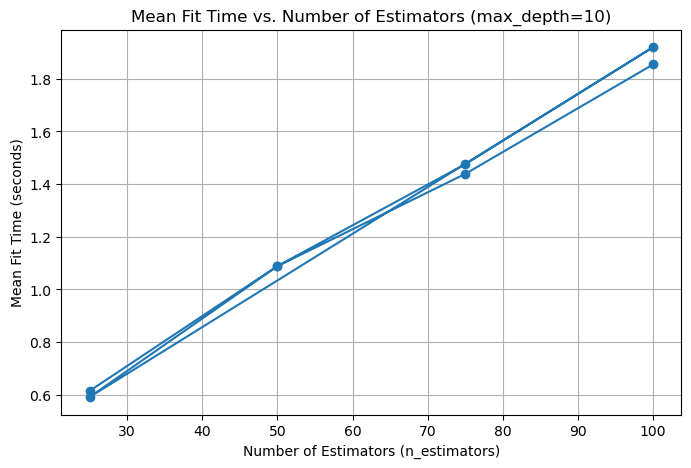

In [13]:
import matplotlib.pyplot as plt

# Convert cv_results_ to a DataFrame for easier manipulation
cv_results_df = pd.DataFrame(model.cv_results_)

# Create a mask for rows where 'param_rf__max_depth' is 10
mask = cv_results_df["param_rf__max_depth"] == 10

# Plot 'param_rf__n_estimators' on x-axis and 'mean_fit_time' on y-axis
plt.figure(figsize=(8, 5))
plt.plot(cv_results_df.loc[mask, "param_rf__n_estimators"], cv_results_df.loc[mask, "mean_fit_time"], marker='o', linestyle='-')

# Labels and title
plt.xlabel("Number of Estimators (n_estimators)")
plt.ylabel("Mean Fit Time (seconds)")
plt.title("Mean Fit Time vs. Number of Estimators (max_depth=10)")
plt.grid(True)

# Show plot
plt.show()


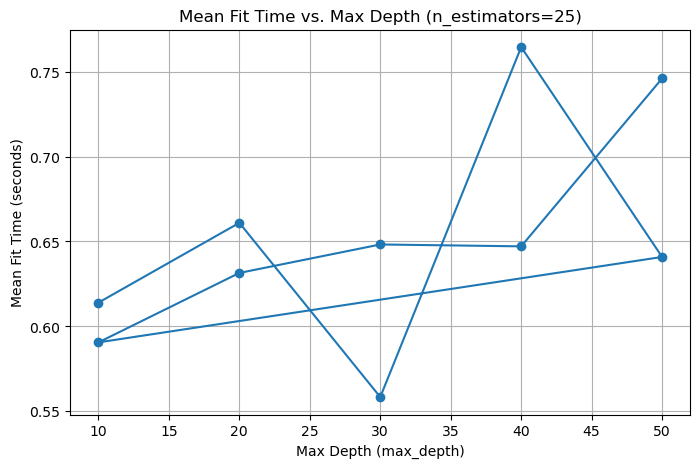

In [14]:
# Create a mask for rows where 'param_rf__n_estimators' is 25
mask = cv_results_df["param_rf__n_estimators"] == 25

# Plot 'param_rf__max_depth' on x-axis and 'mean_fit_time' on y-axis
plt.figure(figsize=(8, 5))
plt.plot(cv_results_df.loc[mask, "param_rf__max_depth"], cv_results_df.loc[mask, "mean_fit_time"], marker='o', linestyle='-')

# Labels and title
plt.xlabel("Max Depth (max_depth)")
plt.ylabel("Mean Fit Time (seconds)")
plt.title("Mean Fit Time vs. Max Depth (n_estimators=25)")
plt.grid(True)

# Show plot
plt.show()


In [15]:
# Extract the best hyparameters
model.predict(X_train_over)

array([0, 0, 0, ..., 1, 1, 1])

In [21]:
# Ensure y_train_over and y_test are of type int
y_train_over = y_train_over.astype(int)
y_test = y_test.astype(int)

# Predict on the training data using the best model
y_train_pred = model.best_estimator_.predict(X_train_over)

# Predict on the test data using the best model
y_test_pred = model.best_estimator_.predict(X_test)

# Calculate training accuracy
train_accuracy = accuracy_score(y_train_over, y_train_pred)

# Calculate test accuracy
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


Training Accuracy: 1.0000
Test Accuracy: 0.9552


In [22]:
y_test.value_counts()

class
0    1109
1      73
Name: count, dtype: int64

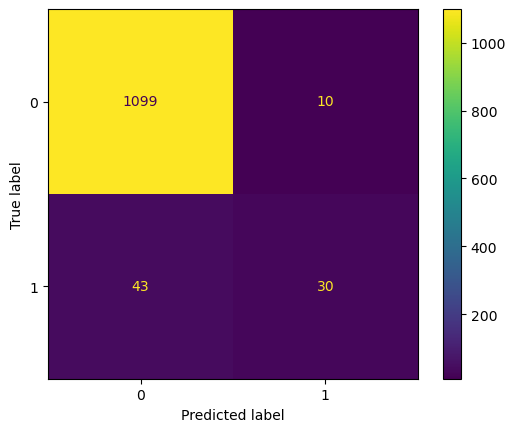

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test);

#### Plot a confusion matrix for the best model

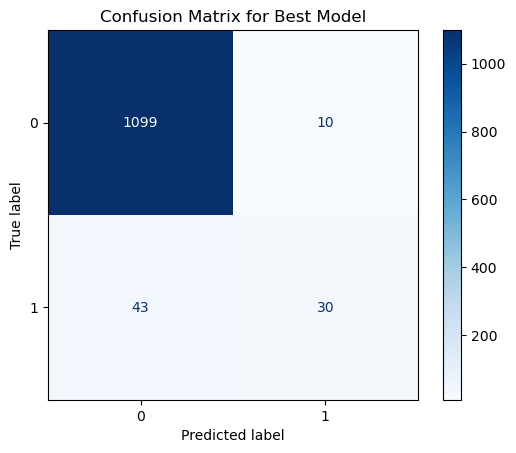

In [28]:
# Predict using the best model on the test set
y_pred_best = model.best_estimator_.predict(X_test)

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred_best)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix for Best Model")
plt.show()

In [30]:
import joblib

# Save the best model to a file
with open("model-5-3.pkl", "wb") as model_file:
    joblib.dump(model.best_estimator_, model_file)


In [35]:
import matplotlib.pyplot as plt
import pandas as pd

# Get feature names from training data
features = X_train.columns

# Extract importances from the RandomForestClassifier inside the pipeline
importances = model.best_estimator_.named_steps['RandomForestClassifier'].feature_importances_

# Create a DataFrame with feature names and their importance values
feat_imp = pd.DataFrame({
    'Feature': features,
    'Importance': importances
})

# Sort the features by importance in descending order
feat_imp = feat_imp.sort_values(by='Importance', ascending=False)

# Plot the 10 most important features
plt.figure(figsize=(10, 6))
feat_imp.head(10).plot(kind='barh', x='Feature', y='Importance', legend=False, color='skyblue')
plt.xlabel("Gini Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances")
plt.gca().invert_yaxis()  # Invert y-axis to show the most important features at the top
plt.show()


KeyError: 'RandomForestClassifier'

<Figure size 1000x600 with 0 Axes>

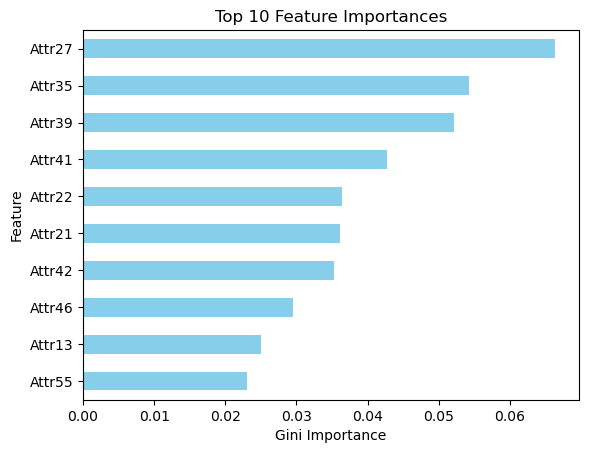

In [38]:
# Get feature names from training data
features = X_train.columns

# Extract importances from the RandomForestClassifier inside the pipeline
if 'rf' in model.best_estimator_.named_steps:  # Replace 'rf' with your actual step name
    importances = model.best_estimator_.named_steps['rf'].feature_importances_
else:
    print("RandomForest step not found in the pipeline.")
    importances = None

if importances is not None:
    # Create a DataFrame with feature names and their importance values
    feat_imp = pd.DataFrame({
        'Feature': features,
        'Importance': importances
    })

    # Sort the features by importance in descending order
    feat_imp = feat_imp.sort_values(by='Importance', ascending=False)

    # Plot the 10 most important features
    plt.figure(figsize=(10, 6))
    feat_imp.head(10).plot(kind='barh', x='Feature', y='Importance', legend=False, color='skyblue')
    plt.xlabel("Gini Importance")
    plt.ylabel("Feature")
    plt.title("Top 10 Feature Importances")
    plt.gca().invert_yaxis()  # Invert y-axis to show the most important features at the top
    plt.show()
else:
    print("No feature importances to plot.");